In [8]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [10]:
def mape(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    mask = y_true != 0
    if mask.sum() == 0:
        return np.nan

    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100


def smape(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2
    mask = denominator != 0
    if mask.sum() == 0:
        return np.nan

    return np.mean(np.abs(y_true[mask] - y_pred[mask]) / denominator[mask]) * 100


def evaluate_forecast(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAPE": mape(y_true, y_pred),
        "sMAPE": smape(y_true, y_pred),
        "R2": r2_score(y_true, y_pred),
    }

In [11]:
SARIMA_FREQ_CONFIG = {
    "15min": {
        "pandas_freq": "15min",
        "seasonal_period": 96,   # 96 x 15 min = 1 day
        "forecast_steps": 96,
    },
    "30min": {
        "pandas_freq": "30min",
        "seasonal_period": 48,   # 48 x 30 min = 1 day
        "forecast_steps": 48,
    },
    "60min": {
        "pandas_freq": "1h",
        "seasonal_period": 24,   # 24 x 60 min = 1 day
        "forecast_steps": 24,
    },
}

In [15]:
def run_sarima_load_forecast_fast(
    df,
    target_col,
    resolution="15min",
    train_ratio=0.80,
    order=(1, 0, 0),
    seasonal_order_base=(0, 1, 1),
    fill_small_gaps=True,
    maxiter=50,
):
    if not isinstance(df.index, pd.DatetimeIndex):
        raise ValueError("df must have a DatetimeIndex.")

    if target_col not in df.columns:
        raise ValueError(f"{target_col} not found in dataframe.")

    SARIMA_FREQ_CONFIG = {
        "15min": {
            "pandas_freq": "15min",
            "seasonal_period": 96,
            "forecast_steps": 96,
        },
        "30min": {
            "pandas_freq": "30min",
            "seasonal_period": 48,
            "forecast_steps": 48,
        },
        "60min": {
            "pandas_freq": "1h",
            "seasonal_period": 24,
            "forecast_steps": 24,
        },
    }

    if resolution not in SARIMA_FREQ_CONFIG:
        raise ValueError("resolution must be one of: '15min', '30min', '60min'.")

    cfg = SARIMA_FREQ_CONFIG[resolution]
    pandas_freq = cfg["pandas_freq"]
    seasonal_period = cfg["seasonal_period"]

    y = df[target_col].copy()
    y = pd.to_numeric(y, errors="coerce")
    y = y.sort_index().asfreq(pandas_freq)

    if fill_small_gaps:
        y = y.interpolate(method="time", limit_direction="both")

    split_idx = int(len(y) * train_ratio)

    y_train = y.iloc[:split_idx].dropna()
    y_test = y.iloc[split_idx:].dropna()

    seasonal_order = (
        seasonal_order_base[0],
        seasonal_order_base[1],
        seasonal_order_base[2],
        seasonal_period,
    )

    print("Training SARIMA model:")
    print("Target:", target_col)
    print("Resolution:", resolution)
    print("Train samples:", len(y_train))
    print("Test samples:", len(y_test))
    print("Order:", order)
    print("Seasonal order:", seasonal_order)

    model = SARIMAX(
        y_train,
        order=order,
        seasonal_order=seasonal_order,
        enforce_stationarity=False,
        enforce_invertibility=False,
        simple_differencing=True,
    )

    fitted_model = model.fit(
        disp=False,
        low_memory=True,
        maxiter=maxiter,
        method="lbfgs",
    )

    forecast = fitted_model.forecast(steps=len(y_test))
    forecast = pd.Series(forecast, index=y_test.index, name="y_pred")

    pred_df = pd.DataFrame({
        "y_true": y_test,
        "y_pred": forecast,
    }).dropna()

    metrics = evaluate_forecast(pred_df["y_true"], pred_df["y_pred"])

    return {
        "model": fitted_model,
        "predictions": pred_df,
        "metrics": metrics,
        "train": y_train,
        "test": y_test,
        "order": order,
        "seasonal_order": seasonal_order,
        "resolution": resolution,
        "target_col": target_col,
    }

In [16]:
path = r"C:\Data_analysis\Thesis\Data\03_Training\Imputed_data\15_min\df_BU_TotActPwr_Academy.parquet"
df = pd.read_parquet(path)

target_col = "BU_TotActPwr_Academy"

print("Data shape:", df.shape)
print("Target:", target_col)

Data shape: (18336, 147)
Target: BU_TotActPwr_Academy


In [20]:
df = df.copy()
df.index = pd.to_datetime(df.index, errors="coerce")
df = df[~df.index.isna()].sort_index()

df_90d = df.loc[df.index >= df.index.max() - pd.Timedelta(days=90)]
print(df_90d.shape)
print(df_90d.index.min(), df_90d.index.max())

(8641, 147)
2026-01-30 23:45:00 2026-04-30 23:45:00


In [22]:
df_90d = df.loc[df.index >= df.index.max() - pd.Timedelta(days=90)]

In [23]:
sarima_15min = run_sarima_load_forecast_fast(
    df=df_90d,
    target_col="BU_TotActPwr_Academy",
    resolution="15min",
    train_ratio=0.80,
    order=(1, 0, 0),
    seasonal_order_base=(0, 1, 1),
    maxiter=30,
)

sarima_15min["metrics"]

Training SARIMA model:
Target: BU_TotActPwr_Academy
Resolution: 15min
Train samples: 6912
Test samples: 1729
Order: (1, 0, 0)
Seasonal order: (0, 1, 1, 96)


{'MAE': 7.072589056776278,
 'RMSE': 8.449470525954712,
 'MAPE': 99.73646837596453,
 'sMAPE': 198.00401231436126,
 'R2': -2.354320168491493}

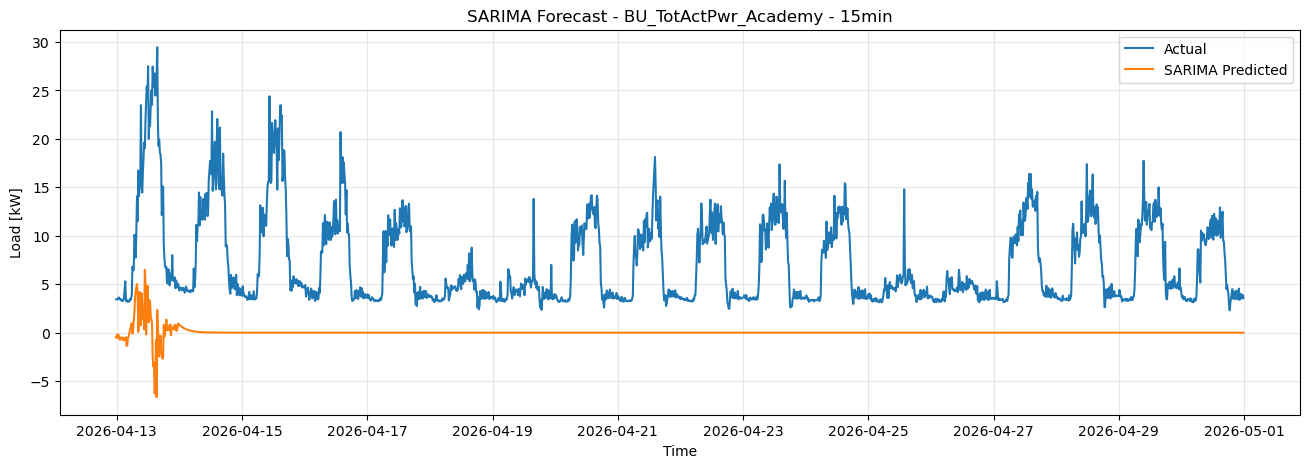

In [24]:
pred_df = sarima_15min["predictions"]

plt.figure(figsize=(16, 5))
plt.plot(pred_df.index, pred_df["y_true"], label="Actual")
plt.plot(pred_df.index, pred_df["y_pred"], label="SARIMA Predicted")
plt.title(f"SARIMA Forecast - {target_col} - 15min")
plt.ylabel("Load [kW]")
plt.xlabel("Time")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [25]:
target_col = "BU_TotActPwr_Academy"

sarima_results = []

for resolution in ["15min", "30min", "60min"]:
    result = run_sarima_load_forecast(
        df=df,
        target_col=target_col,
        resolution=resolution,
        train_ratio=0.80,
        order=(1, 0, 1),
        seasonal_order_base=(1, 1, 1),
    )

    row = {
        "model_name": "SARIMA",
        "target_col": target_col,
        "resolution": resolution,
        "order": result["order"],
        "seasonal_order": result["seasonal_order"],
        **result["metrics"],
    }

    sarima_results.append(row)

sarima_results_df = pd.DataFrame(sarima_results)
sarima_results_df

KeyboardInterrupt: 

In [ ]:
def run_day_ahead_sarima_backtest(
    df,
    target_col,
    resolution="15min",
    train_ratio=0.80,
    order=(1, 0, 1),
    seasonal_order_base=(1, 1, 1),
    max_test_days=None,
):


    if resolution not in SARIMA_FREQ_CONFIG:
        raise ValueError("resolution must be one of: '15min', '30min', '60min'.")

    cfg = SARIMA_FREQ_CONFIG[resolution]
    pandas_freq = cfg["pandas_freq"]
    seasonal_period = cfg["seasonal_period"]
    steps_per_day = cfg["forecast_steps"]

    y = df[target_col].copy()
    y = pd.to_numeric(y, errors="coerce")
    y = y.sort_index().asfreq(pandas_freq)
    y = y.interpolate(method="time", limit_direction="both")

    split_idx = int(len(y) * train_ratio)
    test_start_time = y.index[split_idx]

    test_days = pd.date_range(
        start=test_start_time.normalize(),
        end=y.index.max().normalize(),
        freq="D",
    )

    if max_test_days is not None:
        test_days = test_days[:max_test_days]

    all_predictions = []

    seasonal_order = (
        seasonal_order_base[0],
        seasonal_order_base[1],
        seasonal_order_base[2],
        seasonal_period,
    )

    for day in test_days:
        forecast_start = day
        forecast_end = day + pd.Timedelta(days=1) - pd.Timedelta(pandas_freq)

        y_history = y[y.index < forecast_start].dropna()
        y_actual = y.loc[forecast_start:forecast_end].dropna()

        if len(y_actual) != steps_per_day:
            continue

        try:
            model = SARIMAX(
                y_history,
                order=order,
                seasonal_order=seasonal_order,
                enforce_stationarity=False,
                enforce_invertibility=False,
            )

            fitted_model = model.fit(disp=False)
            y_pred = fitted_model.forecast(steps=steps_per_day)

            pred_day = pd.DataFrame({
                "Time": y_actual.index,
                "forecast_day": day.date(),
                "y_true": y_actual.values,
                "y_pred": np.asarray(y_pred),
            })

            all_predictions.append(pred_day)

        except Exception as e:
            print(f"Skipped {day.date()} because SARIMA failed: {e}")

    predictions_df = pd.concat(all_predictions, ignore_index=True)
    predictions_df = predictions_df.set_index("Time")

    metrics = evaluate_forecast(
        predictions_df["y_true"],
        predictions_df["y_pred"],
    )

    return predictions_df, metrics

In [ ]:
target_col = "BU_TotActPwr_Academy"

all_sarima_rows = []
all_sarima_predictions = {}

for resolution in ["15min", "30min", "60min"]:
    pred_df, metrics = run_day_ahead_sarima_backtest(
        df=df,
        target_col=target_col,
        resolution=resolution,
        train_ratio=0.80,
        order=(1, 0, 1),
        seasonal_order_base=(1, 1, 1),
        max_test_days=20,
    )

    all_sarima_predictions[resolution] = pred_df

    all_sarima_rows.append({
        "model_name": "SARIMA",
        "target_col": target_col,
        "resolution": resolution,
        **metrics,
    })

sarima_comparison_df = pd.DataFrame(all_sarima_rows)
sarima_comparison_df